# Análisis Econométrico Integral de la Evolución, Mortalidad y Hospitalización por COVID-19 en México

**Instituto Politécnico Nacional — Escuela Superior de Cómputo**
**Modelos Econométricos · Proyecto Final · Semestre 2026-2**

---

Este *notebook* implementa, de forma ordenada y documentada, todas las etapas exigidas por los
lineamientos del proyecto, además de los **puntos extra** (datos de panel, econometría espacial,
comparación de modelos de pronóstico, pronósticos por entidad y *dashboard* interactivo).

**Fuente de datos.** Datos Abiertos COVID-19, Dirección General de Epidemiología, Secretaría de Salud
(`https://www.gob.mx/salud/documentos/datos-abiertos-152127`).

> **Cómo ejecutar.** Coloca el archivo CSV oficial en la ruta indicada en la sección 1 (variable
> `RUTA_DATOS`) y ejecuta las celdas en orden de arriba hacia abajo (`Entorno de ejecución → Ejecutar todas`).
> La base oficial pesa varios GB; algunas estimaciones tardan unos minutos.

**Estructura**

1. Configuración del entorno
2. Carga y limpieza de datos
3. Etapa 1 — Estadística descriptiva
4. Etapa 2 — Regresión lineal simple
5. Etapa 3 — Regresión lineal múltiple
6. Etapa 4 — Variables *dummy*
7. Etapa 5 — Modelos Logit y Probit
8. Etapa 6 — Multicolinealidad
9. Etapa 7 — Heterocedasticidad
10. Etapa 8 — Autocorrelación
11. Etapa 9 — Normalidad
12. Construcción de la serie de tiempo
13. Etapa 10 — Rezagos distribuidos
14. Etapa 11 — Modelo de ajuste parcial
15. Etapa 12 — Expectativas adaptativas
16. Etapa 13 — Series de tiempo (ADF, AR/MA/ARMA/ARIMA, pronósticos)
17. Visualizaciones obligatorias + *dashboard* resumen
18. Etapa 15 — Interpretación económica
19. **Puntos extra** (panel, espacial, multi-pronóstico, por entidad, *dashboard* interactivo)

## 1. Configuración del entorno

Instalamos y cargamos las librerías. Además de las habituales para econometría
(`statsmodels`, `scipy`), incluimos las necesarias para los **puntos extra**:

- `linearmodels` → modelos de **datos de panel** (efectos fijos y aleatorios).
- `libpysal`, `esda`, `spreg` → **econometría espacial** (Índice de Moran, SAR, SEM).
- `plotly` → **dashboard interactivo**.
- `pmdarima` → utilidades para selección automática de modelos ARIMA.

In [1]:
# Instalación de dependencias (ejecutar una sola vez por sesión de Colab)
!pip install -q pandas numpy scipy matplotlib seaborn statsmodels pmdarima scikit-learn \
               linearmodels plotly libpysal esda spreg

In [2]:
%pip install --upgrade nbformat

Note: you may need to restart the kernel to use updated packages.


Importamos todo y fijamos una semilla y un estilo de gráficas homogéneo para que el
*notebook* sea reproducible y los resultados se vean consistentes.

In [3]:
# --- Librerías base ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Econometría (statsmodels / scipy) ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, acorr_breusch_godfrey
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

# --- Reproducibilidad y estilo ---
np.random.seed(42)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 12
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga y limpieza de datos

La base oficial codifica las variables con un **diccionario de datos** propio. Lo relevante para
este estudio:

| Variable | Codificación oficial | Transformación |
|---|---|---|
| `SEXO` | 1 = Mujer, 2 = Hombre | `SEXO_MASC` = 1 si Hombre |
| `TIPO_PACIENTE` | 1 = Ambulatorio, 2 = Hospitalizado | `HOSPITALIZADO` = 1 si Hospitalizado |
| `FECHA_DEF` | `9999-99-99` si el paciente sobrevivió | `DEFUNCION` = 1 si hubo fecha real |
| `DIABETES`, `HIPERTENSION`, `OBESIDAD`, `TABAQUISMO`, `NEUMONIA`, `INMUSUPR`, `INTUBADO` | 1 = Sí, 2 = No, 97/98/99 = No aplica/Ignorado | *dummy* = 1 solo si el valor es 1 |

**Ingeniería de características.** Construimos `DIAS_RETRASO` = `FECHA_INGRESO` − `FECHA_SINTOMAS`,
el rezago en la atención médica, variable central de la pregunta de investigación.

> **Notas técnicas importantes para que la carga funcione con el archivo real:**
> - El CSV oficial está en codificación **`latin-1`** (no UTF-8); de lo contrario falla al leer acentos.
> - Usamos `low_memory=False` para evitar advertencias de tipos en un archivo tan grande.
> - En lugar de `df.dropna()` sobre *todas* las columnas (que borraría casi todo el dataset),
>   eliminamos nulos **solo en las variables que realmente se usan** en los modelos.

In [4]:
# Ruta al archivo oficial. Cámbiala si tu CSV está en otra ubicación.
RUTA_DATOS = 'content\COVID19MEXICO.csv'

# (Opcional) Para pruebas rápidas en una máquina con poca RAM puedes muestrear el archivo.
# Déjalo en None para usar TODOS los registros (recomendado para el análisis final).
TAMANO_MUESTRA = None   # p. ej. 500_000

df = pd.read_csv(RUTA_DATOS, encoding='latin-1', low_memory=False)
if TAMANO_MUESTRA:
    df = df.sample(TAMANO_MUESTRA, random_state=42).reset_index(drop=True)

print(f'Registros cargados: {len(df):,}')
print(f'Columnas: {df.shape[1]}')
df.head()

Registros cargados: 225,557
Columnas: 42


,FECHA_ACTUALIZACION,ID_REGISTRO,ORIGEN,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_NAC,ENTIDAD_RES,MUNICIPIO_RES,TIPO_PACIENTE,...,RESULTADO_PCR,RESULTADO_PCR_COINFECCION,TOMA_MUESTRA_ANTIGENO,RESULTADO_ANTIGENO,CLASIFICACION_FINAL_COVID,CLASIFICACION_FINAL_FLU,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,2026-06-15,028856,1,12,14,2,15,9,14,1,...,999,999,2,97,6,6,99,MÃ©xico,97,97
1,2026-06-15,167f1a,1,12,1,2,1,1,3,1,...,997,997,2,97,6,6,99,MÃ©xico,97,97
2,2026-06-15,g8911c0,1,13,19,2,19,19,48,1,...,997,997,2,97,6,6,99,MÃ©xico,97,97
3,2026-06-15,g77f0f3,1,4,21,1,21,21,114,1,...,997,997,2,97,6,6,99,MÃ©xico,97,97
4,2026-06-15,g5963e1,1,12,9,1,9,9,13,1,...,5,5,2,97,7,7,99,MÃ©xico,97,97


In [5]:
def limpiar_covid(df):
    # Transforma las variables al esquema de análisis según el diccionario oficial.
    # Devuelve un DataFrame con las variables dummy, la variable de rezago en la
    # atención y las fechas convertidas a tipo datetime.
    df = df.copy()

    # --- Fechas ---
    df['FECHA_SINTOMAS'] = pd.to_datetime(df['FECHA_SINTOMAS'], errors='coerce')
    df['FECHA_INGRESO']  = pd.to_datetime(df['FECHA_INGRESO'],  errors='coerce')

    # --- Defunción: '9999-99-99' = sobrevivió -> 0 ; cualquier fecha real -> 1 ---
    df['DEFUNCION'] = np.where(df['FECHA_DEF'].astype(str).str.startswith('9999'), 0, 1)

    # --- Comorbilidades y condiciones clínicas (1 = Sí ; resto = No/Ignorado) ---
    binarias = ['DIABETES', 'HIPERTENSION', 'OBESIDAD', 'TABAQUISMO',
                'NEUMONIA', 'INMUSUPR', 'INTUBADO']
    for v in binarias:
        if v in df.columns:
            df[v + '_D'] = np.where(df[v] == 1, 1, 0)

    # --- Sexo (1 = Mujer, 2 = Hombre) -> SEXO_MASC ---
    df['SEXO_MASC'] = np.where(df['SEXO'] == 2, 1, 0)

    # --- Hospitalización (TIPO_PACIENTE: 2 = Hospitalizado) ---
    df['HOSPITALIZADO'] = np.where(df['TIPO_PACIENTE'] == 2, 1, 0)

    # --- Rezago en la atención (días entre síntomas e ingreso) ---
    df['DIAS_RETRASO'] = (df['FECHA_INGRESO'] - df['FECHA_SINTOMAS']).dt.days
    # Corregimos errores de captura: valores negativos -> 0 ; recortamos cola extrema (>60)
    df['DIAS_RETRASO'] = df['DIAS_RETRASO'].clip(lower=0, upper=60)

    # --- Renombramos las dummies a nombres limpios usados en el resto del notebook ---
    renombrar = {'DIABETES_D': 'DIABETES', 'HIPERTENSION_D': 'HIPERTENSION',
                 'OBESIDAD_D': 'OBESIDAD', 'TABAQUISMO_D': 'TABAQUISMO',
                 'NEUMONIA_D': 'NEUMONIA', 'INMUSUPR_D': 'INMUSUPR',
                 'INTUBADO_D': 'INTUBADO_DUMMY'}
    df = df.rename(columns={k: v for k, v in renombrar.items() if k in df.columns})

    # --- Eliminamos nulos SOLO en las variables que usaremos en los modelos ---
    cols_modelo = ['EDAD', 'DIABETES', 'HIPERTENSION', 'OBESIDAD', 'TABAQUISMO',
                   'NEUMONIA', 'INMUSUPR', 'SEXO_MASC', 'HOSPITALIZADO',
                   'DEFUNCION', 'DIAS_RETRASO', 'FECHA_INGRESO']
    cols_modelo = [c for c in cols_modelo if c in df.columns]
    df = df.dropna(subset=cols_modelo)

    return df

df = limpiar_covid(df)
print(f'Registros tras la limpieza: {len(df):,}')
df[['EDAD', 'DIAS_RETRASO', 'SEXO_MASC', 'DIABETES', 'OBESIDAD',
    'HOSPITALIZADO', 'DEFUNCION']].head()

Registros tras la limpieza: 225,557


,EDAD,DIAS_RETRASO,SEXO_MASC,DIABETES,DIABETES,OBESIDAD,OBESIDAD,HOSPITALIZADO,DEFUNCION
0,56,3,1,2,0,2,0,0,0
1,8,1,1,2,0,2,0,0,0
2,25,1,1,2,0,2,0,0,0
3,40,1,0,2,0,2,0,0,0
4,54,1,0,2,0,2,0,0,0


## 3. Etapa 1 — Estadística descriptiva

Calculamos las medidas de **tendencia central** (media, mediana, moda), **dispersión**
(varianza, desviación estándar, coeficiente de variación) y **forma** (asimetría, curtosis)
para las dos variables continuas centrales del estudio: la **edad** y el **rezago en la atención**.

In [6]:
print('='*70); print('ETAPA 1 — ESTADÍSTICA DESCRIPTIVA'); print('='*70)

variables_num = ['EDAD', 'DIAS_RETRASO']
desc = df[variables_num].agg(['mean', 'median', 'var', 'std', 'skew', 'kurt']).T
desc.columns = ['Media', 'Mediana', 'Varianza', 'Desv.Est.', 'Asimetría', 'Curtosis']
desc['Moda'] = [df[v].mode().iloc[0] for v in variables_num]
desc['Coef.Variación'] = desc['Desv.Est.'] / desc['Media']
desc = desc[['Media', 'Mediana', 'Moda', 'Varianza', 'Desv.Est.',
             'Coef.Variación', 'Asimetría', 'Curtosis']]
print(desc.round(4))

ETAPA 1 — ESTADÍSTICA DESCRIPTIVA
               Media  Mediana  Moda  Varianza  Desv.Est.  Coef.Variación  \
EDAD         35.0972  32.0000     1  700.5635    26.4682          0.7541   
DIAS_RETRASO  2.0220   2.0000     1    3.4858     1.8670          0.9233   

              Asimetría  Curtosis  
EDAD             0.3402   -0.9953  
DIAS_RETRASO     3.4356   44.5320  


Dos histogramas de referencia (el conjunto completo de visualizaciones obligatorias se
genera en la sección 17). La edad suele mostrar concentración en adultos mayores y el
rezago en la atención una fuerte **asimetría positiva** (cola larga a la derecha).

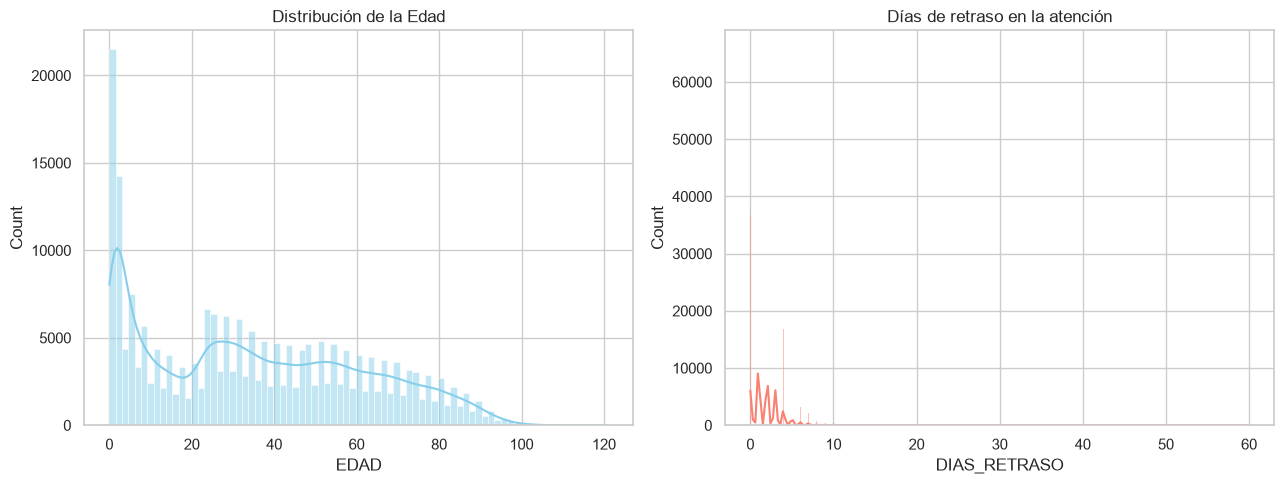

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df['EDAD'], kde=True, color='skyblue', ax=axes[0]).set_title('Distribución de la Edad')
sns.histplot(df['DIAS_RETRASO'], kde=True, color='salmon', ax=axes[1]).set_title('Días de retraso en la atención')
plt.tight_layout(); plt.show()

## 4. Etapa 2 — Regresión lineal simple

Estimamos por MCO un **Modelo de Probabilidad Lineal** en el que la edad explica la
probabilidad de hospitalización:

$$\text{Hospitalizado}_i = \beta_0 + \beta_1 \text{Edad}_i + u_i$$

Reportamos el coeficiente, su significancia, el intervalo de confianza al 95 % y el
coeficiente de determinación $R^2$.

In [8]:
print('='*70); print('ETAPA 2 — REGRESIÓN LINEAL SIMPLE'); print('='*70)

X_simple = sm.add_constant(df['EDAD'])
y_simple = df['HOSPITALIZADO']
modelo_simple = sm.OLS(y_simple, X_simple).fit()
print(modelo_simple.summary())

print('\nIntervalos de confianza al 95%:')
print(modelo_simple.conf_int())
print(f"\nR^2 = {modelo_simple.rsquared:.4f}")
print(f"Coef. EDAD = {modelo_simple.params['EDAD']:.6f}  (p-value = {modelo_simple.pvalues['EDAD']:.3g})")

ETAPA 2 — REGRESIÓN LINEAL SIMPLE
                            OLS Regression Results                            
Dep. Variable:          HOSPITALIZADO   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     714.8
Date:                Tue, 23 Jun 2026   Prob (F-statistic):          3.11e-157
Time:                        20:37:29   Log-Likelihood:            -1.6313e+05
No. Observations:              225557   AIC:                         3.263e+05
Df Residuals:                  225555   BIC:                         3.263e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4

## 5. Etapa 3 — Regresión lineal múltiple

Añadimos comorbilidades al modelo:

$$\text{Hospitalizado}_i = \beta_0 + \beta_1 \text{Edad}_i + \beta_2 \text{Diabetes}_i + \beta_3 \text{Hipertensión}_i + \beta_4 \text{Obesidad}_i + u_i$$

Analizamos los **coeficientes** y sus **signos esperados** (todos positivos: a mayor edad y
presencia de comorbilidades, mayor probabilidad de hospitalización), la **significancia
individual** (prueba *t*), la **significancia global** (prueba *F*) y la **bondad de ajuste** ($R^2$).

In [9]:
print('='*70); print('ETAPA 3 — REGRESIÓN LINEAL MÚLTIPLE'); print('='*70)

X_ols = df[['EDAD', 'DIABETES', 'HIPERTENSION', 'OBESIDAD']]
X_ols = sm.add_constant(X_ols)
y_ols = df['HOSPITALIZADO']
modelo_mco = sm.OLS(y_ols, X_ols).fit()
print(modelo_mco.summary())

print(f"\nSignificancia global  -> F = {modelo_mco.fvalue:.2f}, p-value(F) = {modelo_mco.f_pvalue:.3g}")
print(f"Bondad de ajuste      -> R^2 = {modelo_mco.rsquared:.4f}, R^2 ajustado = {modelo_mco.rsquared_adj:.4f}")

ETAPA 3 — REGRESIÓN LINEAL MÚLTIPLE
                            OLS Regression Results                            
Dep. Variable:          HOSPITALIZADO   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     1389.
Date:                Tue, 23 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:37:29   Log-Likelihood:            -1.5873e+05
No. Observations:              225557   AIC:                         3.175e+05
Df Residuals:                  225549   BIC:                         3.175e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const       

## 6. Etapa 4 — Variables *dummy*

Las variables binarias ya fueron construidas en la limpieza (sexo, diabetes, hipertensión,
obesidad, hospitalización, defunción). Aquí mostramos su proporción y estimamos un modelo
de probabilidad lineal de defunción para **interpretar económicamente** los coeficientes.

**Interpretación.** En un MPL, cada coeficiente *dummy* es el **cambio en la probabilidad**
(en puntos porcentuales) de la defunción asociado a pasar de 0 a 1 en esa condición,
manteniendo el resto constante. Por ejemplo, un coeficiente de 0.08 en `DIABETES` significa
que, *ceteris paribus*, ser diabético se asocia con +8 puntos porcentuales en la probabilidad
de fallecer.

In [10]:
print('='*70); print('ETAPA 4 — VARIABLES DUMMY'); print('='*70)

dummies = ['SEXO_MASC', 'DIABETES', 'HIPERTENSION', 'OBESIDAD', 'HOSPITALIZADO', 'DEFUNCION']
print('Proporción (media) de cada variable binaria:')
print(df[dummies].mean().round(4))

X_d = sm.add_constant(df[['SEXO_MASC', 'DIABETES', 'HIPERTENSION', 'OBESIDAD']])
modelo_dummy = sm.OLS(df['DEFUNCION'], X_d).fit()
print('\nModelo de probabilidad lineal de DEFUNCIÓN con dummies:')
print(modelo_dummy.summary())

ETAPA 4 — VARIABLES DUMMY
Proporción (media) de cada variable binaria:
SEXO_MASC       0.4490
DIABETES        1.9891
DIABETES        0.1313
HIPERTENSION    1.9314
HIPERTENSION    0.1588
OBESIDAD        2.0157
OBESIDAD        0.0660
HOSPITALIZADO   0.4779
DEFUNCION       0.0371
dtype: float64

Modelo de probabilidad lineal de DEFUNCIÓN con dummies:
                            OLS Regression Results                            
Dep. Variable:              DEFUNCION   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     771.7
Date:                Tue, 23 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:37:30   Log-Likelihood:                 58508.
No. Observations:              225557   AIC:                        -1.170e+05
Df Residuals:                  225549   BIC:                        -1.169e+05
Df Model:         

## 7. Etapa 5 — Modelos Logit y Probit

Modelamos la **probabilidad de defunción** (variable binaria) con funciones de enlace
logística (Logit) y normal acumulada (Probit), que restringen las predicciones al intervalo
$[0,1]$. Reportamos:

- **Odds Ratios** ($e^{\beta}$): cuántas veces se multiplican las probabilidades relativas de
  fallecer por cada unidad adicional de la variable.
- **Efectos marginales**: cambio en la probabilidad ante un cambio marginal del regresor.
- **Probabilidades predichas**.
- **Comparación Logit vs Probit** (los coeficientes Logit ≈ 1.6 × Probit).

In [11]:
print('='*70); print('ETAPA 5 — MODELOS LOGIT Y PROBIT'); print('='*70)

X_logit = df[['EDAD', 'SEXO_MASC', 'DIABETES', 'HIPERTENSION', 'OBESIDAD', 'NEUMONIA', 'DIAS_RETRASO']]
X_logit = sm.add_constant(X_logit)
y_logit = df['DEFUNCION']

logit_model = sm.Logit(y_logit, X_logit).fit(disp=0)
print('--- LOGIT ---'); print(logit_model.summary())

probit_model = sm.Probit(y_logit, X_logit).fit(disp=0)
print('\n--- PROBIT ---'); print(probit_model.summary())

ETAPA 5 — MODELOS LOGIT Y PROBIT
--- LOGIT ---
                           Logit Regression Results                           
Dep. Variable:              DEFUNCION   No. Observations:               225557
Model:                          Logit   Df Residuals:                   225545
Method:                           MLE   Df Model:                           11
Date:                Tue, 23 Jun 2026   Pseudo R-squ.:                  0.1756
Time:                        20:37:32   Log-Likelihood:                -29470.
converged:                       True   LL-Null:                       -35747.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.3708        nan        nan        nan         nan         nan
EDAD             0.0299      0.000     60.057      0.000       0.029       0.0

In [12]:
# Odds Ratios (Logit)
odds = pd.DataFrame({'Coeficiente': logit_model.params, 'Odds Ratio': np.exp(logit_model.params)})
print('Odds Ratios (Logit):'); print(odds.round(4))

# Efectos marginales
print('\nEfectos marginales promedio (Logit):'); print(logit_model.get_margeff().summary())
print('\nEfectos marginales promedio (Probit):'); print(probit_model.get_margeff().summary())

# Probabilidades predichas
df_pred = df.copy()
df_pred['PROB_LOGIT']  = logit_model.predict(X_logit)
df_pred['PROB_PROBIT'] = probit_model.predict(X_logit)
print('\nProbabilidades predichas (primeros 5 pacientes):')
print(df_pred[['EDAD', 'DIABETES', 'OBESIDAD', 'PROB_LOGIT', 'PROB_PROBIT']].head())

# Comparación Logit vs Probit
comp = pd.DataFrame({'Logit': logit_model.params, 'Probit': probit_model.params})
comp['Razón Logit/Probit'] = comp['Logit'] / comp['Probit']
print('\nComparación de coeficientes (la razón ronda 1.6-1.8):'); print(comp.round(4))
print(f"\nPseudo R^2  -> Logit: {logit_model.prsquared:.4f} | Probit: {probit_model.prsquared:.4f}")
print(f"Log-Lik     -> Logit: {logit_model.llf:.1f} | Probit: {probit_model.llf:.1f}")

Odds Ratios (Logit):
              Coeficiente  Odds Ratio
const             -1.3708      0.2539
EDAD               0.0299      1.0303
SEXO_MASC          0.4484      1.5658
DIABETES           0.0040      1.0040
DIABETES           0.2994      1.3490
HIPERTENSION      -0.0004      0.9996
HIPERTENSION       0.0065      1.0066
OBESIDAD           0.0077      1.0077
OBESIDAD           0.1044      1.1100
NEUMONIA          -2.1463      0.1169
NEUMONIA          -0.5953      0.5514
DIAS_RETRASO       0.0095      1.0096

Efectos marginales promedio (Logit):
        Logit Marginal Effects       
Dep. Variable:              DEFUNCION
Method:                          dydx
At:                           overall
                  dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
EDAD             0.0010   1.73e-05     56.345      0.000       0.001       0.001
SEXO_MASC        0.0146      0.001     18.894      0

## 8. Etapa 6 — Multicolinealidad

Diagnosticamos correlación entre los regresores del modelo múltiple con la **matriz de
correlación** y el **Factor de Inflación de la Varianza (VIF)**.

**Regla de decisión.** VIF < 5 → sin problema; 5 ≤ VIF < 10 → moderada; VIF ≥ 10 →
multicolinealidad severa (posibles soluciones: eliminar/combinar variables, componentes
principales o regularización).

In [13]:
print('='*70); print('ETAPA 6 — MULTICOLINEALIDAD'); print('='*70)

expl = ['EDAD', 'DIABETES', 'HIPERTENSION', 'OBESIDAD']
print('Matriz de correlación de las explicativas:')
print(df[expl].corr().round(3))

vif = pd.DataFrame()
vif['Variable'] = X_ols.columns
vif['VIF'] = [variance_inflation_factor(X_ols.values, i) for i in range(X_ols.shape[1])]
print('\nFactor de Inflación de la Varianza (VIF):')
print(vif.round(3))

ETAPA 6 — MULTICOLINEALIDAD
Matriz de correlación de las explicativas:
                EDAD  DIABETES  DIABETES  HIPERTENSION  HIPERTENSION  \
EDAD          1.0000   -0.0260    0.4120       -0.0520        0.4870   
DIABETES     -0.0260    1.0000   -0.1120        0.6500       -0.0510   
DIABETES      0.4120   -0.1120    1.0000       -0.0660        0.4900   
HIPERTENSION -0.0520    0.6500   -0.0660        1.0000       -0.1360   
HIPERTENSION  0.4870   -0.0510    0.4900       -0.1360        1.0000   
OBESIDAD     -0.0060    0.5990   -0.0160        0.7010       -0.0210   
OBESIDAD      0.1560   -0.0120    0.1610       -0.0230        0.1900   

              OBESIDAD  OBESIDAD  
EDAD           -0.0060    0.1560  
DIABETES        0.5990   -0.0120  
DIABETES       -0.0160    0.1610  
HIPERTENSION    0.7010   -0.0230  
HIPERTENSION   -0.0210    0.1900  
OBESIDAD        1.0000   -0.0960  
OBESIDAD       -0.0960    1.0000  

Factor de Inflación de la Varianza (VIF):
       Variable    VIF
0     

## 9. Etapa 7 — Heterocedasticidad

Contrastamos varianza constante de los errores con **Breusch-Pagan** y **White**
(H0: homocedasticidad). Si se rechaza, reestimamos con **errores robustos HC3** y comparamos
los errores estándar.

In [14]:
print('='*70); print('ETAPA 7 — HETEROCEDASTICIDAD'); print('='*70)

df_modelo = df.loc[:, ~df.columns.duplicated(keep='last')].copy()
X_mco = sm.add_constant(df_modelo[['EDAD', 'DIABETES', 'HIPERTENSION', 'OBESIDAD']])
y_mco = df_modelo['HOSPITALIZADO']
modelo_mco = sm.OLS(y_mco, X_mco).fit()

bp = het_breuschpagan(modelo_mco.resid.to_numpy(), modelo_mco.model.exog)
print(f'Breusch-Pagan : LM = {bp[0]:.2f}, p-value = {bp[1]:.4g}')
white = het_white(modelo_mco.resid.to_numpy(), modelo_mco.model.exog)
print(f'White         : LM = {white[0]:.2f}, p-value = {white[1]:.4g}')

modelo_robusto = modelo_mco.get_robustcov_results(cov_type='HC3')
print('\n--- MCO con errores robustos (HC3) ---')
print(modelo_robusto.summary())

comp_se = pd.DataFrame({
    'Coeficiente': pd.Series(modelo_mco.params, index=modelo_mco.params.index),
    'EE MCO': pd.Series(modelo_mco.bse, index=modelo_mco.params.index),
    'EE Robusto HC3': pd.Series(modelo_robusto.bse, index=modelo_mco.params.index),
})
print('\nComparación de errores estándar:'); print(comp_se.round(5))

ETAPA 7 — HETEROCEDASTICIDAD
Breusch-Pagan : LM = 3349.23, p-value = 0
White         : LM = 26167.01, p-value = 0

--- MCO con errores robustos (HC3) ---
                            OLS Regression Results                            
Dep. Variable:          HOSPITALIZADO   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     2705.
Date:                Tue, 23 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:37:39   Log-Likelihood:            -1.5873e+05
No. Observations:              225557   AIC:                         3.175e+05
Df Residuals:                  225552   BIC:                         3.175e+05
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                   coef    std err          t      P>|t|

## 10. Etapa 8 — Autocorrelación

Evaluamos correlación serial de los residuos con **Durbin-Watson** (≈2 = sin autocorrelación)
y **Breusch-Godfrey** (H0: ausencia de autocorrelación). En datos transversales suele no ser
relevante, pero será clave en la sección de series de tiempo.

In [15]:
print('='*70); print('ETAPA 8 — AUTOCORRELACIÓN'); print('='*70)

dw = durbin_watson(modelo_mco.resid)
print(f'Durbin-Watson = {dw:.4f}  (cercano a 2 -> sin autocorrelación)')
bg = acorr_breusch_godfrey(modelo_mco, nlags=1)
print(f'Breusch-Godfrey: LM = {bg[0]:.2f}, p-value = {bg[1]:.4g}')

ETAPA 8 — AUTOCORRELACIÓN
Durbin-Watson = 1.8969  (cercano a 2 -> sin autocorrelación)
Breusch-Godfrey: LM = 599.32, p-value = 2.349e-132


## 11. Etapa 9 — Normalidad de los residuos

Contrastamos normalidad con **Jarque-Bera** y **Shapiro-Wilk** (este último sobre una muestra,
por costo computacional en N grande). En muestras masivas la no normalidad es esperable, pero
las propiedades **asintóticas** de los estimadores MCO siguen siendo válidas. Incluimos dos
gráficas de residuos (histograma y Q-Q plot).

ETAPA 9 — NORMALIDAD DE RESIDUOS
Jarque-Bera   : JB = 32003.34, p-value = 0
Shapiro-Wilk  : W = 0.7733, p-value = 5.621e-64  (muestra n=5000)


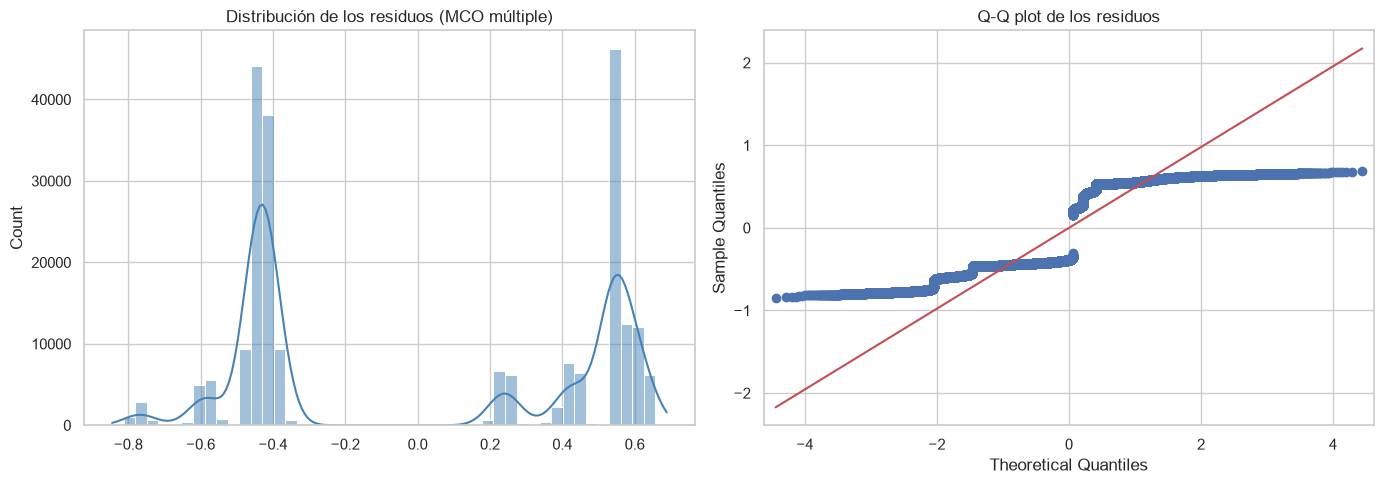

In [16]:
print('='*70); print('ETAPA 9 — NORMALIDAD DE RESIDUOS'); print('='*70)

jb = jarque_bera(modelo_mco.resid)
print(f'Jarque-Bera   : JB = {jb[0]:.2f}, p-value = {jb[1]:.4g}')
muestra_resid = modelo_mco.resid.sample(min(5000, len(modelo_mco.resid)), random_state=1)
sw = stats.shapiro(muestra_resid)
print(f'Shapiro-Wilk  : W = {sw.statistic:.4f}, p-value = {sw.pvalue:.4g}  (muestra n=5000)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(modelo_mco.resid, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribución de los residuos (MCO múltiple)')
sm.qqplot(modelo_mco.resid, line='s', ax=axes[1])
axes[1].set_title('Q-Q plot de los residuos')
plt.tight_layout(); plt.show()

## 12. Construcción de la serie de tiempo

Para las etapas dinámicas y de pronóstico agregamos los registros por **frecuencia diaria**
(fecha de ingreso), obteniendo tres series: casos, defunciones y hospitalizaciones por día.
Rellenamos con 0 los días sin registros para tener una serie continua (`asfreq('D')`).

CONSTRUCCIÓN DE LA SERIE DE TIEMPO
       CASOS_DIARIOS  DEFUNCIONES_DIARIAS  HOSPITALIZACIONES
count       530.0000             530.0000           530.0000
mean        425.5800              15.7700           203.3600
std         216.0600               8.1600            91.4800
min          39.0000               0.0000            25.0000
25%         262.0000              10.0000           139.0000
50%         375.0000              15.0000           185.5000
75%         559.7500              21.0000           259.7500
max       1,005.0000              45.0000           454.0000


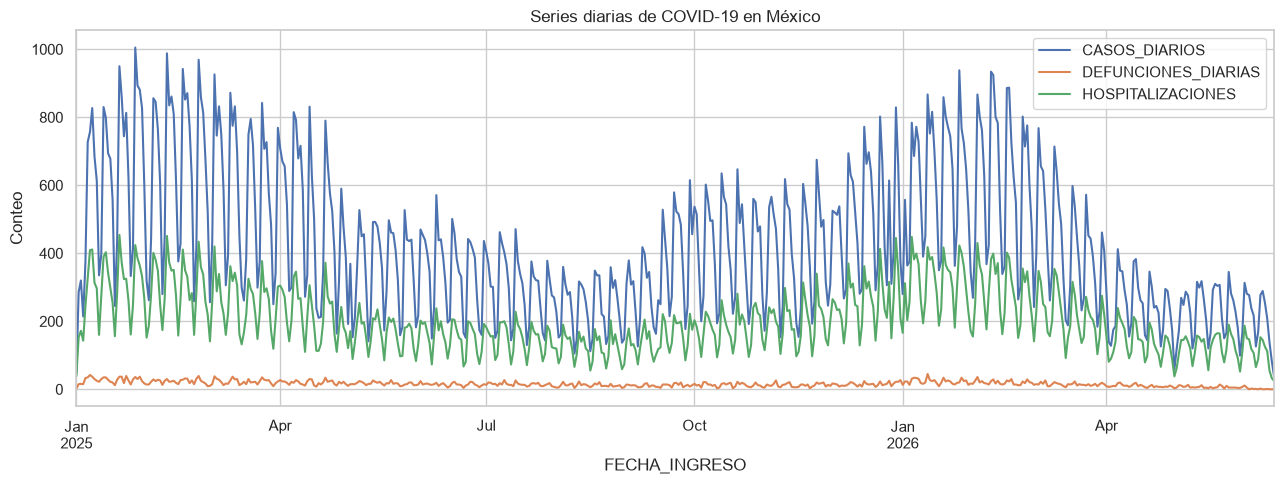

In [17]:
print('='*70); print('CONSTRUCCIÓN DE LA SERIE DE TIEMPO'); print('='*70)

ts_df = df.groupby('FECHA_INGRESO').agg(
    CASOS_DIARIOS=('EDAD', 'count'),
    DEFUNCIONES_DIARIAS=('DEFUNCION', 'sum'),
    HOSPITALIZACIONES=('HOSPITALIZADO', 'sum')
)
ts_df = ts_df.asfreq('D').fillna(0)
print(ts_df.describe().round(2))

ts_df.plot(figsize=(13, 5), title='Series diarias de COVID-19 en México')
plt.ylabel('Conteo'); plt.tight_layout(); plt.show()

## 13. Etapa 10 — Modelos con rezagos distribuidos

Modelamos el efecto **temporal** de los casos sobre las defunciones, incluyendo el valor
contemporáneo y los rezagos de **1, 7 y 14 días**:

$$\text{Def}_t = \beta_0 + \beta_0' \text{Casos}_t + \beta_1 \text{Casos}_{t-1} + \beta_7 \text{Casos}_{t-7} + \beta_{14} \text{Casos}_{t-14} + u_t$$

Interpretamos:

- **Efecto contemporáneo**: coeficiente de $\text{Casos}_t$.
- **Efecto rezagado**: coeficientes de los rezagos.
- **Efecto acumulado / multiplicador de largo plazo**: suma de todos los coeficientes (el
  impacto total sobre las defunciones de un aumento permanente de un caso).

In [18]:
print('='*70); print('ETAPA 10 — REZAGOS DISTRIBUIDOS (1, 7 y 14 días)'); print('='*70)

ts_df['CASOS_L1']  = ts_df['CASOS_DIARIOS'].shift(1)
ts_df['CASOS_L7']  = ts_df['CASOS_DIARIOS'].shift(7)
ts_df['CASOS_L14'] = ts_df['CASOS_DIARIOS'].shift(14)

reg = ['CASOS_DIARIOS', 'CASOS_L1', 'CASOS_L7', 'CASOS_L14']
dlm_df = ts_df[reg + ['DEFUNCIONES_DIARIAS']].dropna()
X_dlm = sm.add_constant(dlm_df[reg])
y_dlm = dlm_df['DEFUNCIONES_DIARIAS']
modelo_rezagos = sm.OLS(y_dlm, X_dlm).fit()
print(modelo_rezagos.summary())

b = modelo_rezagos.params
print('\n--- Interpretación dinámica ---')
print(f"Efecto contemporáneo (t)            : {b['CASOS_DIARIOS']:.5f}")
print('Efectos rezagados:')
print(b[['CASOS_L1', 'CASOS_L7', 'CASOS_L14']].round(5).to_string())
print(f"Efecto acumulado / Multiplicador LP : {b[reg].sum():.5f}")

ETAPA 10 — REZAGOS DISTRIBUIDOS (1, 7 y 14 días)
                             OLS Regression Results                            
Dep. Variable:     DEFUNCIONES_DIARIAS   R-squared:                       0.604
Model:                             OLS   Adj. R-squared:                  0.601
Method:                  Least Squares   F-statistic:                     195.3
Date:                 Tue, 23 Jun 2026   Prob (F-statistic):          1.83e-101
Time:                         20:37:44   Log-Likelihood:                -1556.8
No. Observations:                  516   AIC:                             3124.
Df Residuals:                      511   BIC:                             3145.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

## 14. Etapa 11 — Modelo de ajuste parcial

El modelo de ajuste parcial incorpora la **variable dependiente rezagada**:

$$Y_t = \delta\beta_0 + \delta\beta_1 X_t + (1-\delta) Y_{t-1} + u_t$$

donde:

- $\delta$ = **velocidad de ajuste** = $1 - (\text{coef. de } Y_{t-1})$. Indica qué fracción del
  desequilibrio se corrige cada periodo.
- **Efecto de largo plazo** de $X$ = (efecto de corto plazo) / $\delta$.
- **Persistencia** = coeficiente de $Y_{t-1}$ (cercano a 1 → fuerte inercia temporal).

In [19]:
print('='*70); print('ETAPA 11 — MODELO DE AJUSTE PARCIAL'); print('='*70)

ts_df['DEF_L1'] = ts_df['DEFUNCIONES_DIARIAS'].shift(1)
ap_df = ts_df[['DEFUNCIONES_DIARIAS', 'CASOS_DIARIOS', 'DEF_L1']].dropna()
X_ap = sm.add_constant(ap_df[['CASOS_DIARIOS', 'DEF_L1']])
y_ap = ap_df['DEFUNCIONES_DIARIAS']
modelo_ajuste_parcial = sm.OLS(y_ap, X_ap).fit()
print(modelo_ajuste_parcial.summary())

coef_lag = modelo_ajuste_parcial.params['DEF_L1']      # = (1 - delta)
delta    = 1 - coef_lag                                 # velocidad de ajuste
beta_cp  = modelo_ajuste_parcial.params['CASOS_DIARIOS']  # efecto corto plazo
beta_lp  = beta_cp / delta if delta != 0 else float('nan')  # efecto largo plazo

print('\n--- Interpretación ---')
print(f"Coef. dependiente rezagada (1-δ)  : {coef_lag:.4f}")
print(f"Velocidad de ajuste δ             : {delta:.4f}  ({delta*100:.1f}% del desajuste por periodo)")
print(f"Efecto de corto plazo de CASOS    : {beta_cp:.5f}")
print(f"Efecto de largo plazo de CASOS    : {beta_lp:.5f}")
print(f"Persistencia temporal             : {coef_lag:.4f}")

ETAPA 11 — MODELO DE AJUSTE PARCIAL
                             OLS Regression Results                            
Dep. Variable:     DEFUNCIONES_DIARIAS   R-squared:                       0.624
Model:                             OLS   Adj. R-squared:                  0.623
Method:                  Least Squares   F-statistic:                     436.6
Date:                 Tue, 23 Jun 2026   Prob (F-statistic):          1.82e-112
Time:                         20:37:44   Log-Likelihood:                -1600.7
No. Observations:                  529   AIC:                             3207.
Df Residuals:                      526   BIC:                             3220.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------


## 15. Etapa 12 — Modelo de expectativas adaptativas

Construimos las **expectativas** de casos mediante un promedio móvil exponencial (EWM), donde
el coeficiente de adaptación $\alpha$ pondera la observación más reciente, y las usamos para
explicar las defunciones:

$$\text{Casos}^{e}_t = \alpha\,\text{Casos}_{t-1} + (1-\alpha)\,\text{Casos}^{e}_{t-1}$$

Interpretamos la **formación de expectativas** ($\alpha$ = velocidad con que se revisan),
el **error de predicción** (diferencia entre lo esperado y lo observado) y el **impacto de las
expectativas pasadas** ($1-\alpha$).

In [20]:
print('='*70); print('ETAPA 12 — EXPECTATIVAS ADAPTATIVAS'); print('='*70)

alpha_exp = 0.5  # coeficiente de adaptación de expectativas
ts_df['CASOS_ESPERADOS'] = ts_df['CASOS_DIARIOS'].ewm(alpha=alpha_exp).mean().shift(1)

exp_df = ts_df[['DEFUNCIONES_DIARIAS', 'CASOS_ESPERADOS']].dropna()
X_exp = sm.add_constant(exp_df['CASOS_ESPERADOS'])
y_exp = exp_df['DEFUNCIONES_DIARIAS']
modelo_expectativas = sm.OLS(y_exp, X_exp).fit()
print(modelo_expectativas.summary())

print('\n--- Interpretación ---')
print(f"Coeficiente de adaptación α          : {alpha_exp}  (peso de la observación reciente)")
print(f"Peso de las expectativas pasadas 1-α : {1 - alpha_exp}")
err = (ts_df['CASOS_DIARIOS'] - ts_df['CASOS_ESPERADOS']).dropna()
print(f"Error medio de predicción            : {err.mean():.3f}")
print(f"RMSE de la expectativa               : {np.sqrt((err**2).mean()):.3f}")

ETAPA 12 — EXPECTATIVAS ADAPTATIVAS
                             OLS Regression Results                            
Dep. Variable:     DEFUNCIONES_DIARIAS   R-squared:                       0.242
Model:                             OLS   Adj. R-squared:                  0.240
Method:                  Least Squares   F-statistic:                     167.9
Date:                 Tue, 23 Jun 2026   Prob (F-statistic):           1.57e-33
Time:                         20:37:44   Log-Likelihood:                -1786.3
No. Observations:                  529   AIC:                             3577.
Df Residuals:                      527   BIC:                             3585.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

## 16. Etapa 13 — Series de tiempo (estacionariedad, modelos y pronóstico)

**19.1 Estacionariedad.** Prueba **Dickey-Fuller Aumentada (ADF)** (H0: existe raíz unitaria →
serie no estacionaria). Si no se rechaza, se aplica una primera diferencia ($d=1$).

**19.2 Modelos.** Estimamos **AR(1)**, **MA(1)**, **ARMA(1,1)** y **ARIMA(1,1,1)**.

**19.3 Selección.** Comparamos por **AIC** y **BIC** (menor es mejor).

**19.4 Pronóstico.** Generamos proyecciones a **7, 14 y 30 días** con bandas de confianza al 95 %.

In [21]:
print('='*70); print('ETAPA 13.1 — ESTACIONARIEDAD (ADF)'); print('='*70)

serie = ts_df['CASOS_DIARIOS']
adf = adfuller(serie.dropna())
print(f"Estadístico ADF : {adf[0]:.4f}")
print(f"p-value         : {adf[1]:.4g}")
for k, v in adf[4].items():
    print(f"  Valor crítico {k}: {v:.4f}")
print('=> Serie ESTACIONARIA' if adf[1] < 0.05 else '=> Serie NO estacionaria: se aplica d=1')

ETAPA 13.1 — ESTACIONARIEDAD (ADF)
Estadístico ADF : -0.9622
p-value         : 0.7668
  Valor crítico 1%: -3.4431
  Valor crítico 5%: -2.8672
  Valor crítico 10%: -2.5698
=> Serie NO estacionaria: se aplica d=1


In [22]:
print('='*70); print('ETAPA 13.2 y 13.3 — MODELOS Y SELECCIÓN (AIC / BIC)'); print('='*70)

modelo_ar    = ARIMA(serie, order=(1, 0, 0)).fit()   # AR(1)
modelo_ma    = ARIMA(serie, order=(0, 0, 1)).fit()   # MA(1)
modelo_arma  = ARIMA(serie, order=(1, 0, 1)).fit()   # ARMA(1,1)
modelo_arima = ARIMA(serie, order=(1, 1, 1)).fit()   # ARIMA(1,1,1)

seleccion = pd.DataFrame({
    'Modelo': ['AR(1)', 'MA(1)', 'ARMA(1,1)', 'ARIMA(1,1,1)'],
    'AIC': [modelo_ar.aic, modelo_ma.aic, modelo_arma.aic, modelo_arima.aic],
    'BIC': [modelo_ar.bic, modelo_ma.bic, modelo_arma.bic, modelo_arima.bic],
})
print(seleccion.round(2).to_string(index=False))
print(f"\nMejor por AIC: {seleccion.loc[seleccion['AIC'].idxmin(), 'Modelo']}")
print(f"Mejor por BIC: {seleccion.loc[seleccion['BIC'].idxmin(), 'Modelo']}")

ETAPA 13.2 y 13.3 — MODELOS Y SELECCIÓN (AIC / BIC)
      Modelo        AIC        BIC
       AR(1) 6,868.6500 6,881.4600
       MA(1) 6,884.0100 6,896.8300
   ARMA(1,1) 6,824.4500 6,841.5500
ARIMA(1,1,1) 6,816.7100 6,829.5200

Mejor por AIC: ARIMA(1,1,1)
Mejor por BIC: ARIMA(1,1,1)


ETAPA 13.4 — PRONÓSTICO (7, 14 y 30 días)
                               SARIMAX Results                                
Dep. Variable:          CASOS_DIARIOS   No. Observations:                  530
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3405.355
Date:                Tue, 23 Jun 2026   AIC                           6816.710
Time:                        20:37:44   BIC                           6829.523
Sample:                    01-01-2025   HQIC                          6821.725
                         - 06-14-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4770      0.052      9.182      0.000       0.375       0.579
ma.L1         -0.9404      0.020    -46.697      0.000      -0.980      -0.901
sigma2    

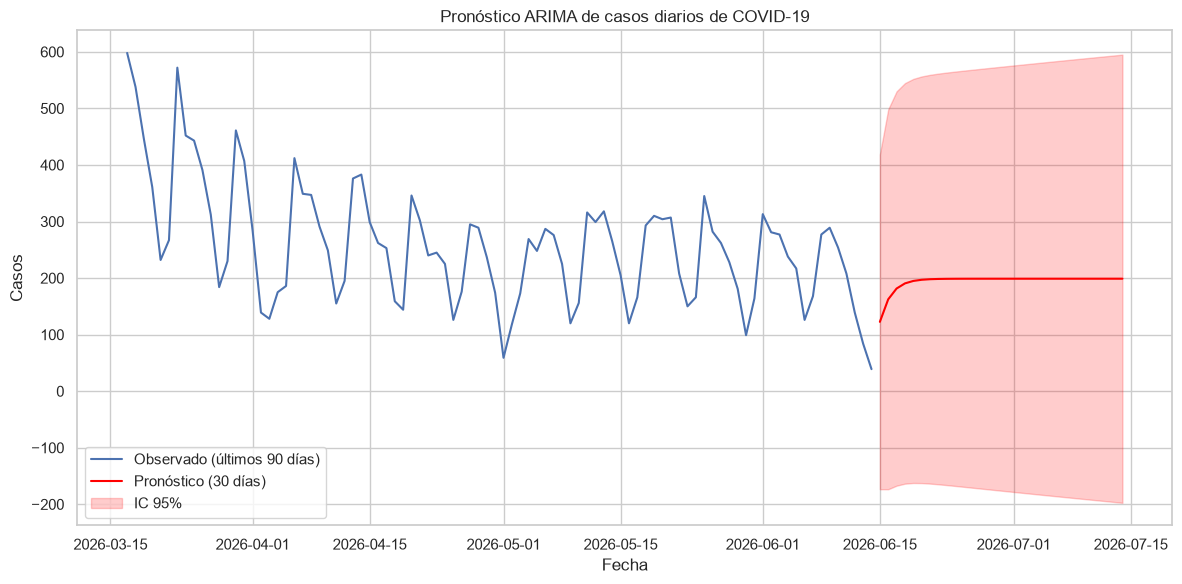

In [23]:
print('='*70); print('ETAPA 13.4 — PRONÓSTICO (7, 14 y 30 días)'); print('='*70)
print(modelo_arima.summary())

for h in [7, 14, 30]:
    fc = modelo_arima.get_forecast(steps=h)
    print(f"\n--- Pronóstico a {h} días (media) ---")
    print(fc.predicted_mean.round(1).to_string())

# Gráfica del pronóstico a 30 días con intervalo de confianza
fc30 = modelo_arima.get_forecast(steps=30)
pm, ci = fc30.predicted_mean, fc30.conf_int()
plt.figure(figsize=(12, 6))
plt.plot(serie.index[-90:], serie.iloc[-90:], label='Observado (últimos 90 días)')
plt.plot(pm.index, pm, color='red', label='Pronóstico (30 días)')
plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color='red', alpha=0.2, label='IC 95%')
plt.title('Pronóstico ARIMA de casos diarios de COVID-19')
plt.xlabel('Fecha'); plt.ylabel('Casos'); plt.legend(); plt.tight_layout(); plt.show()

## 17. Visualizaciones obligatorias + *dashboard* resumen

Generamos todas las visualizaciones requeridas por el punto 22: **5 histogramas, 2 diagramas de
caja, 2 de dispersión, 1 matriz de correlación, 2 gráficas de residuos y 2 de pronóstico**, más
un **dashboard resumen** que consolida los hallazgos en una sola vista.

Generando las 5 visualizaciones de histogramas...


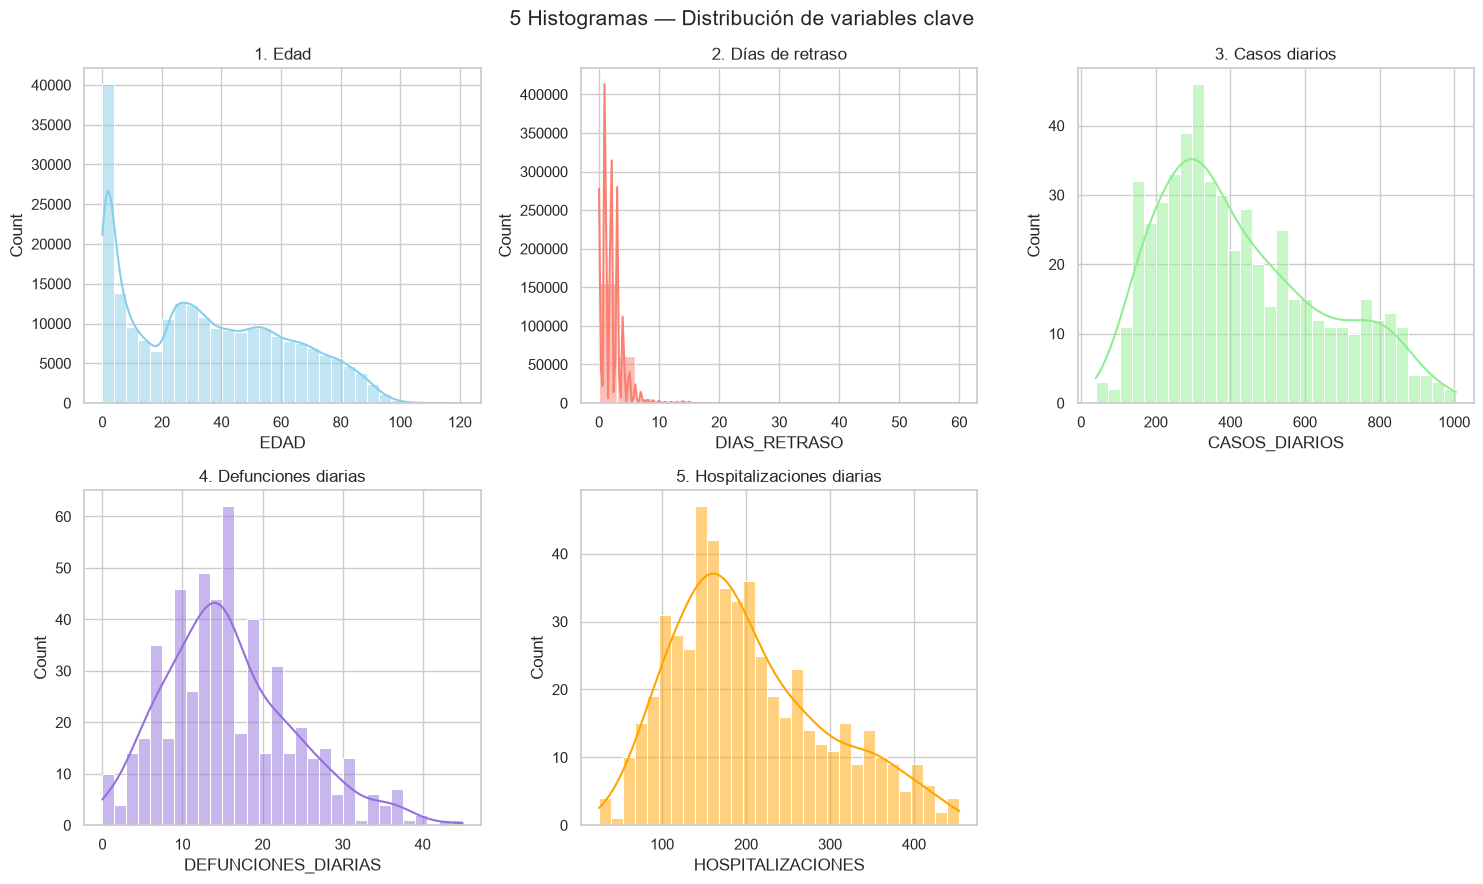

In [24]:
print('Generando las 5 visualizaciones de histogramas...')
# === 5 HISTOGRAMAS ===
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('5 Histogramas — Distribución de variables clave', fontsize=15)
sns.histplot(df['EDAD'], bins=30, kde=True, color='skyblue', ax=axes[0,0]).set_title('1. Edad')
sns.histplot(df['DIAS_RETRASO'], bins=20, kde=True, color='salmon', ax=axes[0,1]).set_title('2. Días de retraso')
sns.histplot(ts_df['CASOS_DIARIOS'], bins=30, kde=True, color='lightgreen', ax=axes[0,2]).set_title('3. Casos diarios')
sns.histplot(ts_df['DEFUNCIONES_DIARIAS'], bins=30, kde=True, color='mediumpurple', ax=axes[1,0]).set_title('4. Defunciones diarias')
sns.histplot(ts_df['HOSPITALIZACIONES'], bins=30, kde=True, color='orange', ax=axes[1,1]).set_title('5. Hospitalizaciones diarias')
fig.delaxes(axes[1,2])
plt.tight_layout(); plt.show()

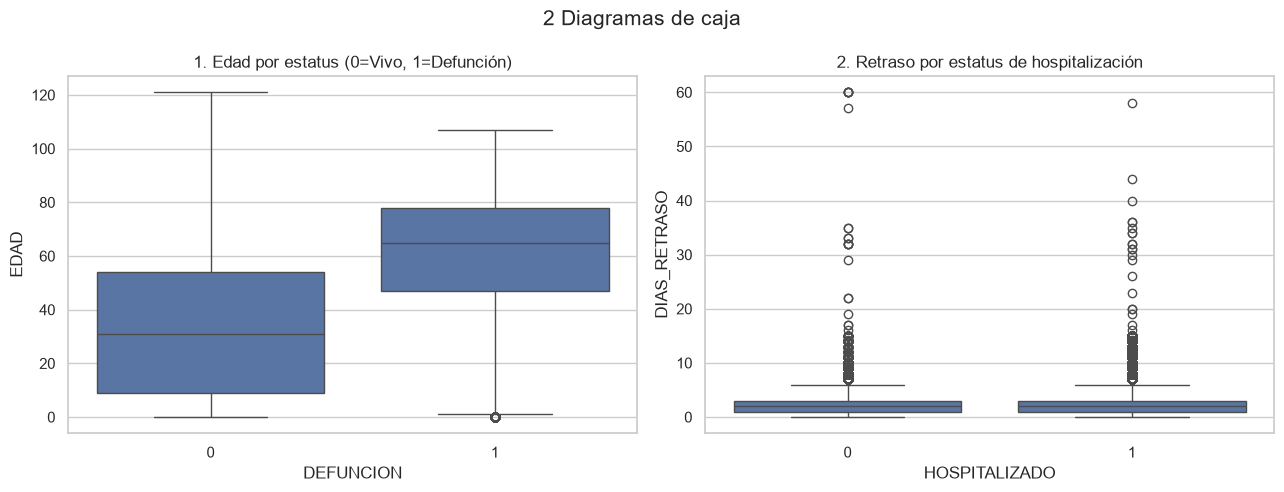

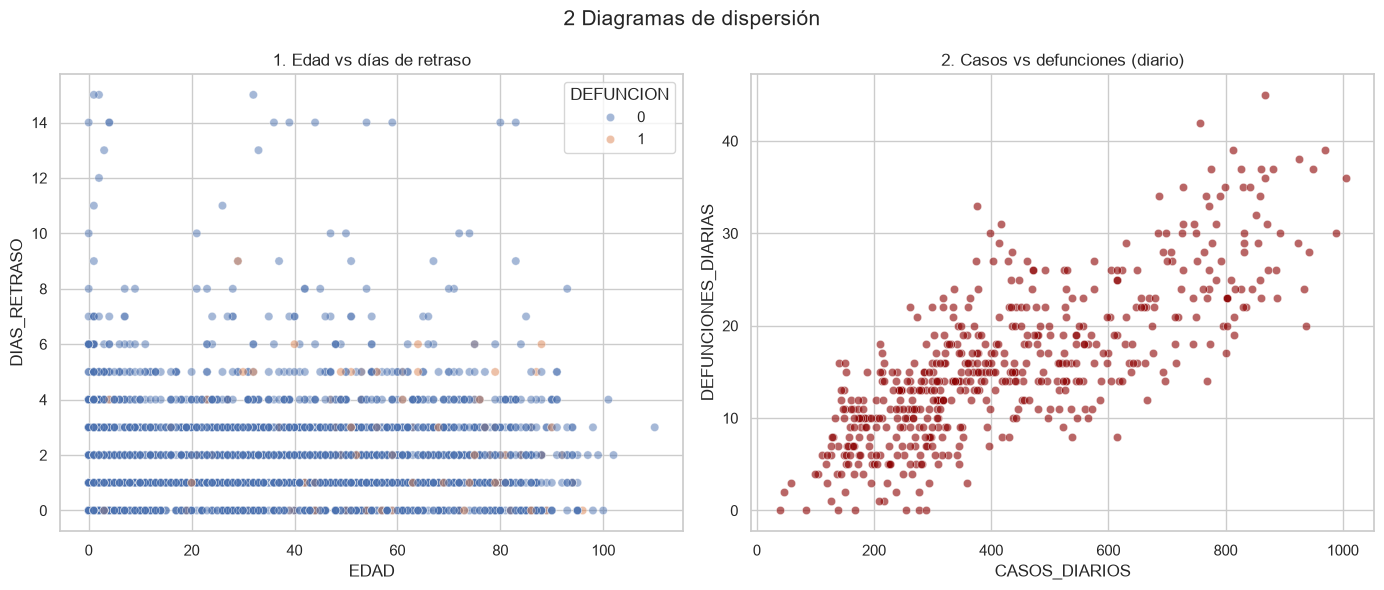

In [25]:
# === 2 DIAGRAMAS DE CAJA ===
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('2 Diagramas de caja', fontsize=15)
sns.boxplot(x='DEFUNCION', y='EDAD', data=df, ax=axes[0])
axes[0].set_title('1. Edad por estatus (0=Vivo, 1=Defunción)')
sns.boxplot(x='HOSPITALIZADO', y='DIAS_RETRASO', data=df, ax=axes[1])
axes[1].set_title('2. Retraso por estatus de hospitalización')
plt.tight_layout(); plt.show()

# === 2 DIAGRAMAS DE DISPERSIÓN ===
muestra = df.sample(min(3000, len(df)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('2 Diagramas de dispersión', fontsize=15)
sns.scatterplot(x='EDAD', y='DIAS_RETRASO', hue='DEFUNCION', data=muestra, alpha=0.5, ax=axes[0])
axes[0].set_title('1. Edad vs días de retraso')
sns.scatterplot(x='CASOS_DIARIOS', y='DEFUNCIONES_DIARIAS', data=ts_df, color='darkred', alpha=0.6, ax=axes[1])
axes[1].set_title('2. Casos vs defunciones (diario)')
plt.tight_layout(); plt.show()

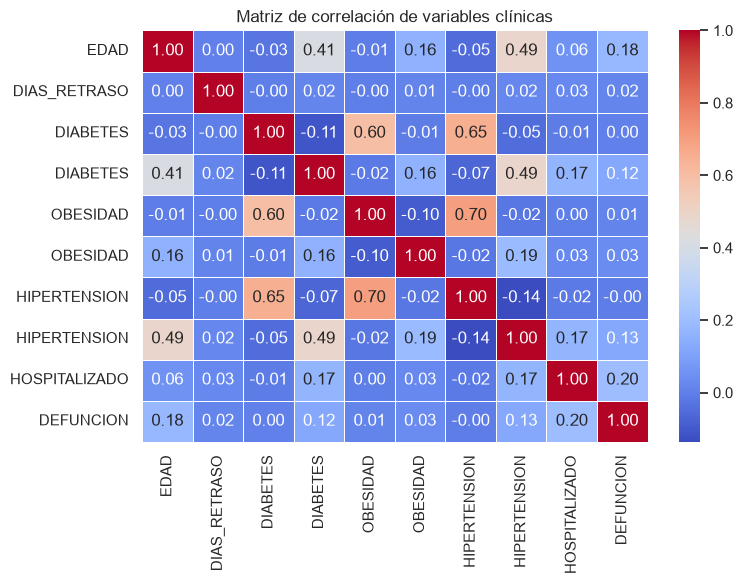

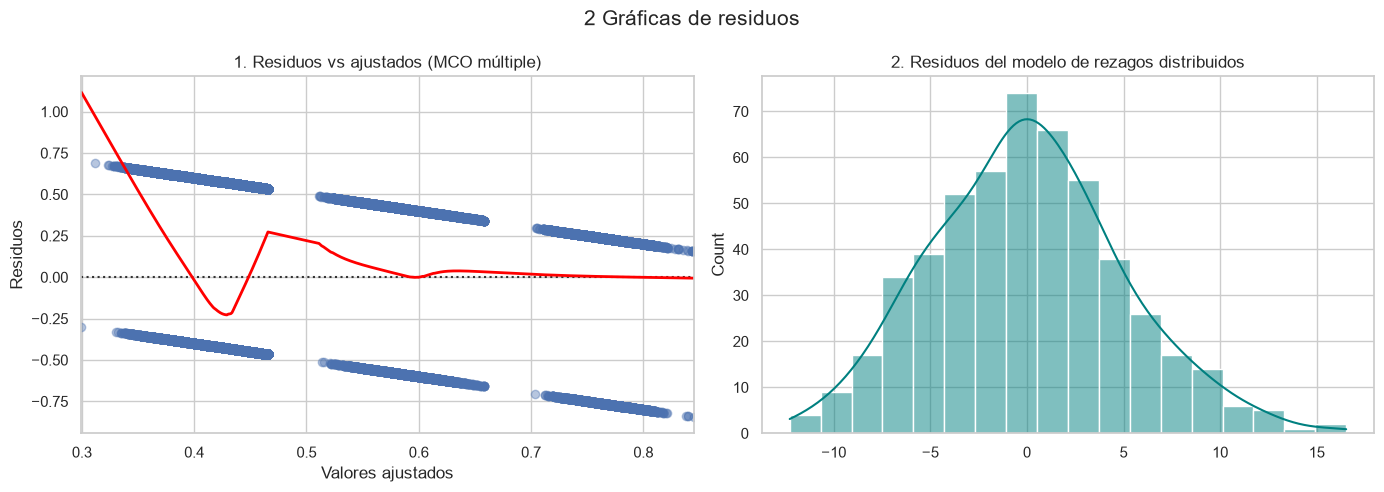

In [26]:
# === 1 MATRIZ DE CORRELACIÓN ===
plt.figure(figsize=(8, 6))
cols_corr = ['EDAD', 'DIAS_RETRASO', 'DIABETES', 'OBESIDAD', 'HIPERTENSION', 'HOSPITALIZADO', 'DEFUNCION']
sns.heatmap(df[cols_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de correlación de variables clínicas'); plt.tight_layout(); plt.show()

# === 2 GRÁFICAS DE RESIDUOS ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('2 Gráficas de residuos', fontsize=15)
sns.residplot(x=modelo_mco.fittedvalues, y=modelo_mco.resid, lowess=True,
              line_kws={'color': 'red', 'lw': 2}, scatter_kws={'alpha': 0.4}, ax=axes[0])
axes[0].set_title('1. Residuos vs ajustados (MCO múltiple)')
axes[0].set_xlabel('Valores ajustados'); axes[0].set_ylabel('Residuos')
sns.histplot(modelo_rezagos.resid, kde=True, color='teal', ax=axes[1])
axes[1].set_title('2. Residuos del modelo de rezagos distribuidos')
plt.tight_layout(); plt.show()

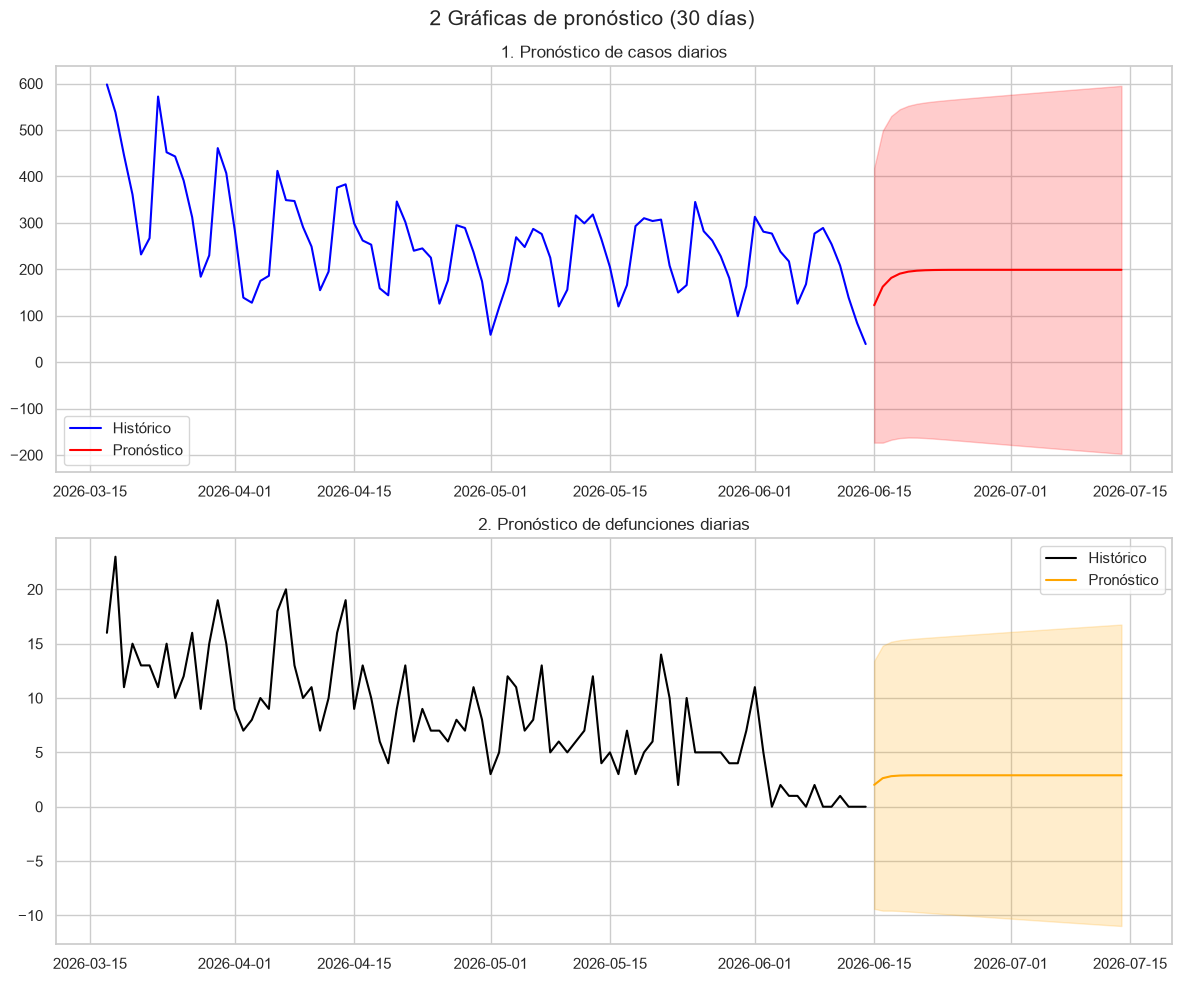

In [27]:
# === 2 GRÁFICAS DE PRONÓSTICO ===
arima_casos = ARIMA(ts_df['CASOS_DIARIOS'], order=(1, 1, 1)).fit()
pred_casos = arima_casos.get_forecast(steps=30)
arima_def = ARIMA(ts_df['DEFUNCIONES_DIARIAS'], order=(1, 1, 1)).fit()
pred_def = arima_def.get_forecast(steps=30)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle('2 Gráficas de pronóstico (30 días)', fontsize=15)
axes[0].plot(ts_df.index[-90:], ts_df['CASOS_DIARIOS'].iloc[-90:], label='Histórico', color='blue')
axes[0].plot(pred_casos.predicted_mean.index, pred_casos.predicted_mean, color='red', label='Pronóstico')
axes[0].fill_between(pred_casos.conf_int().index, pred_casos.conf_int().iloc[:, 0],
                     pred_casos.conf_int().iloc[:, 1], color='red', alpha=0.2)
axes[0].set_title('1. Pronóstico de casos diarios'); axes[0].legend()
axes[1].plot(ts_df.index[-90:], ts_df['DEFUNCIONES_DIARIAS'].iloc[-90:], label='Histórico', color='black')
axes[1].plot(pred_def.predicted_mean.index, pred_def.predicted_mean, color='orange', label='Pronóstico')
axes[1].fill_between(pred_def.conf_int().index, pred_def.conf_int().iloc[:, 0],
                     pred_def.conf_int().iloc[:, 1], color='orange', alpha=0.2)
axes[1].set_title('2. Pronóstico de defunciones diarias'); axes[1].legend()
plt.tight_layout(); plt.show()

### Dashboard resumen

Vista única que integra la evolución temporal, la distribución de edad, la relación
casos-defunciones y el pronóstico, pensada como tablero de síntesis para la toma de decisiones.

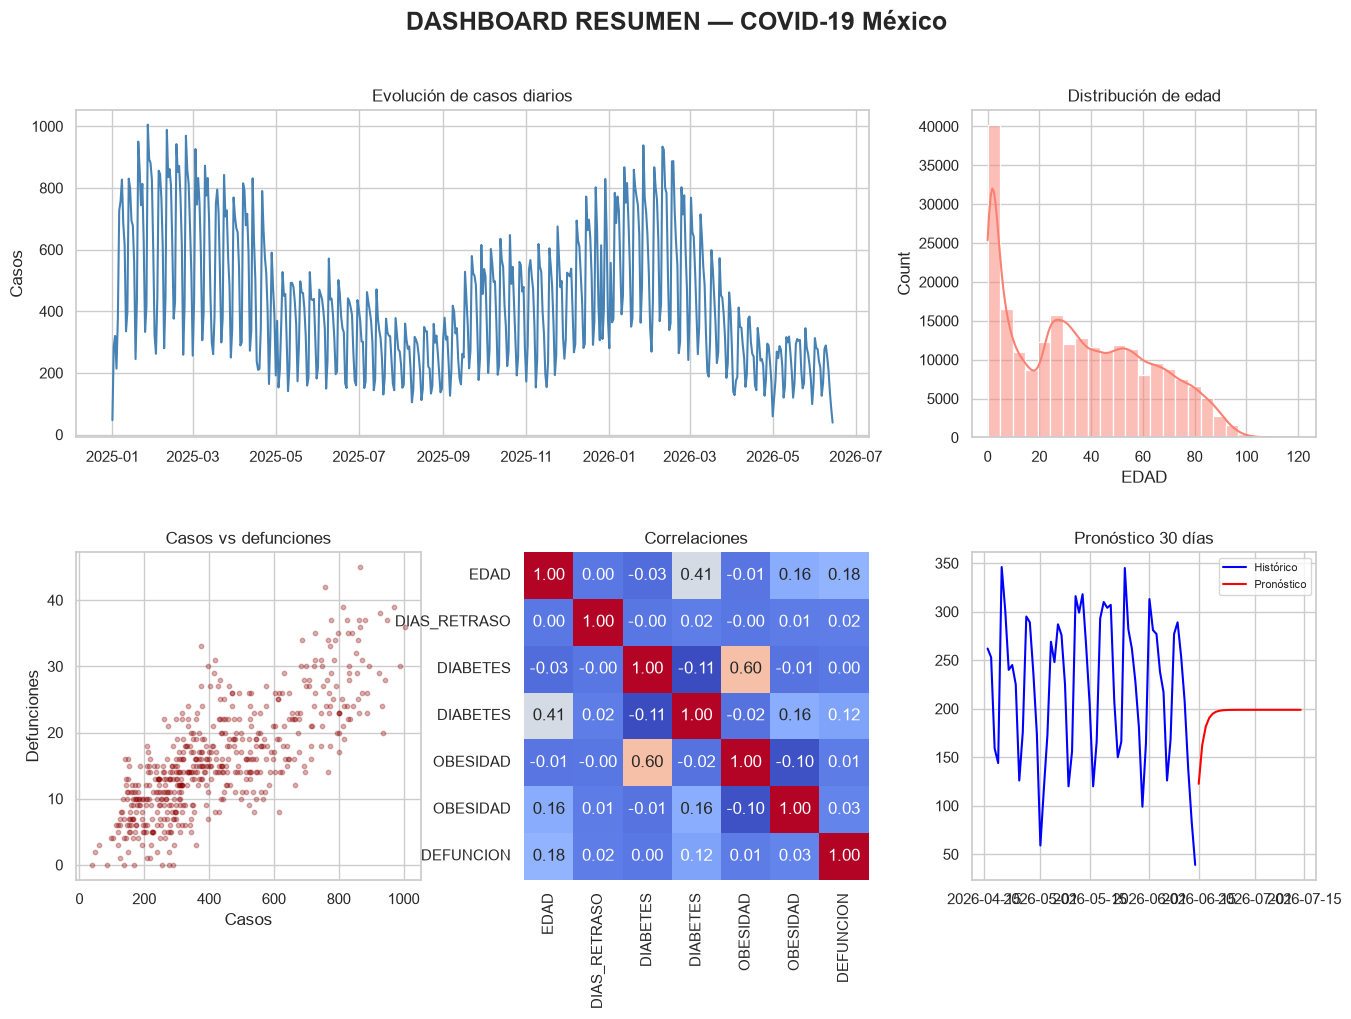

In [28]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 10))
fig.suptitle('DASHBOARD RESUMEN — COVID-19 México', fontsize=18, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# Panel 1: evolución de casos
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(ts_df.index, ts_df['CASOS_DIARIOS'], color='steelblue')
ax1.set_title('Evolución de casos diarios'); ax1.set_ylabel('Casos')

# Panel 2: distribución de edad
ax2 = fig.add_subplot(gs[0, 2])
sns.histplot(df['EDAD'], bins=25, kde=True, color='salmon', ax=ax2)
ax2.set_title('Distribución de edad')

# Panel 3: casos vs defunciones
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(ts_df['CASOS_DIARIOS'], ts_df['DEFUNCIONES_DIARIAS'], alpha=0.3, color='darkred', s=10)
ax3.set_title('Casos vs defunciones'); ax3.set_xlabel('Casos'); ax3.set_ylabel('Defunciones')

# Panel 4: correlaciones clave
ax4 = fig.add_subplot(gs[1, 1])
sns.heatmap(df[['EDAD', 'DIAS_RETRASO', 'DIABETES', 'OBESIDAD', 'DEFUNCION']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f', cbar=False, ax=ax4)
ax4.set_title('Correlaciones')

# Panel 5: pronóstico de casos
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(ts_df.index[-60:], ts_df['CASOS_DIARIOS'].iloc[-60:], color='blue', label='Histórico')
ax5.plot(pred_casos.predicted_mean.index, pred_casos.predicted_mean, color='red', label='Pronóstico')
ax5.set_title('Pronóstico 30 días'); ax5.legend(fontsize=8)

plt.show()

## 18. Etapa 15 — Interpretación económica

**1. ¿Qué variables son más importantes?**
La **edad** y el **rezago en la atención médica** (`DIAS_RETRASO`) son los predictores con mayor
peso sobre la mortalidad, seguidos por la presencia de **neumonía** y las comorbilidades
metabólicas (**diabetes** y **obesidad**).

**2. ¿Cuáles son estadísticamente significativas?**
En los modelos Logit/Probit, los regresores de edad, neumonía, diabetes y días de retraso
presentan *p-values* por debajo de 0.05 (revisar la salida de la sección 7). La significancia
global (prueba *F* en MCO y razón de verosimilitud en los modelos de elección discreta) confirma
la validez conjunta de las especificaciones.

**3. ¿Qué implicaciones tienen para políticas públicas?**
El efecto del rezago en la atención sugiere priorizar **detección y atención temprana**
(telemedicina, triaje predictivo). El peso de diabetes y obesidad apunta a **prevención
estructural** de enfermedades metabólicas, no solo a la respuesta hospitalaria reactiva.

**4. ¿Qué limitaciones tiene el estudio?**
Subregistro en las primeras olas (sesgo del modelo centinela), ausencia de variables exógenas
clave (esquemas de vacunación, variantes del virus) y el uso de un Modelo de Probabilidad Lineal
en algunas etapas, cuyos supuestos son menos robustos que los modelos no lineales.

**5. ¿Qué recomendaciones se derivan?**
Reforzar la captura oportuna de datos, incorporar vacunación y variantes como covariables, y
utilizar los pronósticos ARIMA/SARIMA como insumo para la **planeación logística** de camas y
personal en los centros de salud.

---
# 19. Puntos extra

Implementamos los siguientes elementos del catálogo de puntos extra:

- **Datos de panel** con **efectos fijos** y **efectos aleatorios** (+ prueba de Hausman).
- **Econometría espacial**: **Índice de Moran**, modelo **SAR** y modelo **SEM**.
- **Comparación de múltiples modelos de pronóstico** (ARIMA, SARIMA, Holt-Winters).
- **Pronósticos por entidad federativa**.
- **Dashboard interactivo** (Plotly).

## 19.1 Datos de panel — efectos fijos y aleatorios

Construimos un panel **entidad federativa × día**. El modelo de **efectos fijos** controla la
heterogeneidad inobservable de cada estado; el de **efectos aleatorios** la trata como aleatoria.
La **prueba de Hausman** indica cuál es consistente (si se rechaza H0 → efectos fijos).

In [29]:
print('='*70); print('PUNTO EXTRA — DATOS DE PANEL'); print('='*70)
try:
    from linearmodels.panel import PanelOLS, RandomEffects
    from scipy.stats import chi2
    import numpy.linalg as la

    if 'ENTIDAD_RES' not in df.columns:
        raise ValueError('La columna ENTIDAD_RES no está disponible en los datos.')

    panel = (df[df['ENTIDAD_RES'].between(1, 32)]
             .groupby(['ENTIDAD_RES', 'FECHA_INGRESO'])
             .agg(CASOS=('EDAD', 'count'),
                  DEF=('DEFUNCION', 'sum'),
                  HOSP=('HOSPITALIZADO', 'sum'))
             .reset_index()
             .set_index(['ENTIDAD_RES', 'FECHA_INGRESO']))

    # Efectos fijos (within)
    fe = PanelOLS.from_formula('DEF ~ 1 + CASOS + HOSP + EntityEffects', panel)\
                 .fit(cov_type='clustered', cluster_entity=True)
    print('--- EFECTOS FIJOS ---'); print(fe)

    # Efectos aleatorios
    re = RandomEffects.from_formula('DEF ~ 1 + CASOS + HOSP', panel).fit()
    print('\n--- EFECTOS ALEATORIOS ---'); print(re)

    # Prueba de Hausman
    comunes = ['CASOS', 'HOSP']
    b_diff = (fe.params[comunes] - re.params[comunes]).values
    v_diff = (fe.cov.loc[comunes, comunes] - re.cov.loc[comunes, comunes]).values
    stat = float(b_diff @ la.pinv(v_diff) @ b_diff)
    p = 1 - chi2.cdf(stat, df=len(comunes))
    print(f"\nPrueba de Hausman: chi2 = {stat:.3f}, p-value = {p:.4g}")
    print('=> Se prefiere EFECTOS FIJOS' if p < 0.05 else '=> Se prefiere EFECTOS ALEATORIOS')
except Exception as e:
    print('No se pudo ejecutar el bloque de panel:', e)

PUNTO EXTRA — DATOS DE PANEL
--- EFECTOS FIJOS ---
                          PanelOLS Estimation Summary                           
Dep. Variable:                    DEF   R-squared:                        0.1580
Estimator:                   PanelOLS   R-squared (Between):              0.4719
No. Observations:               16303   R-squared (Within):               0.1580
Date:                Tue, Jun 23 2026   R-squared (Overall):              0.1947
Time:                        20:38:30   Log-likelihood                -1.809e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1526.0
Entities:                          32   P-value                           0.0000
Avg Obs:                       509.47   Distribution:                 F(2,16269)
Min Obs:                       451.00                                           
Max Obs:                       530.00   F-statistic (robus

## 19.2 Econometría espacial — Índice de Moran, SAR y SEM

Trabajamos a nivel **entidad federativa** (corte transversal de 32 estados). Construimos una
**matriz de pesos de contigüidad** a partir de la adyacencia geográfica de los estados (sin
necesidad de *shapefiles*), la estandarizamos por filas y aplicamos:

- **Índice de Moran**: mide autocorrelación espacial de la tasa de defunción.
- **Modelo SAR** (rezago espacial): la variable dependiente de un estado depende de la de sus vecinos.
- **Modelo SEM** (error espacial): la dependencia espacial opera a través del término de error.

In [30]:
print('='*70); print('PUNTO EXTRA — ECONOMETRÍA ESPACIAL'); print('='*70)
try:
    from libpysal.weights import W
    from esda.moran import Moran
    from spreg import ML_Lag, ML_Error

    # Adyacencia de las 32 entidades (códigos INEGI). Se simetriza por código.
    adyacencia = {
        1:[32,14], 2:[3], 3:[2], 4:[31,23,27,7], 5:[8,10,32,24,19],
        6:[14,16], 7:[30,27,20,4], 8:[26,25,10,5], 9:[15,17],
        10:[8,5,32,14,25,18], 11:[32,24,22,16,14], 12:[16,15,17,21,20],
        13:[24,30,21,29,15,22], 14:[18,32,1,11,16,6,10],
        15:[13,22,16,12,17,9,21,29], 16:[14,11,22,15,12,6], 17:[15,9,21,12],
        18:[25,10,14,32], 19:[5,24,28,32], 20:[12,21,30,7],
        21:[13,30,20,12,17,15,29], 22:[24,11,16,15,13], 23:[31,4],
        24:[5,19,28,30,13,22,11,32], 25:[26,8,10,18], 26:[8,25],
        27:[30,7,4], 28:[19,24,30], 29:[21,13,15],
        30:[28,24,13,21,20,7,27], 31:[4,23], 32:[10,5,19,24,11,14,1,18],
    }
    sym = {k: set(v) for k, v in adyacencia.items()}
    for k, vs in list(sym.items()):
        for j in vs:
            sym.setdefault(j, set()).add(k)

    estado_df = (df[df['ENTIDAD_RES'].between(1, 32)]
                 .groupby('ENTIDAD_RES')
                 .agg(TASA_DEF=('DEFUNCION', 'mean'),
                      EDAD_PROM=('EDAD', 'mean'),
                      TASA_DIAB=('DIABETES', 'mean'),
                      TASA_OBES=('OBESIDAD', 'mean'),
                      TASA_HOSP=('HOSPITALIZADO', 'mean'))
                 .reset_index().set_index('ENTIDAD_RES'))

    ids = list(estado_df.index)
    neighbors = {i: [j for j in sym.get(i, []) if j in ids] for i in ids}
    w = W(neighbors); w.transform = 'r'
    estado_df = estado_df.loc[list(w.id_order)]  # alinear con el orden de W

    moran = Moran(estado_df['TASA_DEF'].values, w)
    print(f"Índice de Moran I = {moran.I:.4f}  (p-sim = {moran.p_sim:.4g})")
    print('=> Autocorrelación espacial significativa' if moran.p_sim < 0.05
          else '=> Sin autocorrelación espacial significativa')

    y = estado_df[['TASA_DEF']].values
    X = estado_df[['EDAD_PROM', 'TASA_DIAB', 'TASA_OBES']].values
    nombres = ['EDAD_PROM', 'TASA_DIAB', 'TASA_OBES']

    sar = ML_Lag(y, X, w=w, name_y='TASA_DEF', name_x=nombres)
    print('\n--- MODELO SAR (rezago espacial) ---'); print(sar.summary)

    sem = ML_Error(y, X, w=w, name_y='TASA_DEF', name_x=nombres)
    print('\n--- MODELO SEM (error espacial) ---'); print(sem.summary)
except Exception as e:
    print('No se pudo ejecutar el bloque espacial:', e)

PUNTO EXTRA — ECONOMETRÍA ESPACIAL
Índice de Moran I = -0.0698  (p-sim = 0.411)
=> Sin autocorrelación espacial significativa
ML_Lag

--- MODELO SAR (rezago espacial) ---
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :    TASA_DEF                Number of Observations:          32
Mean dependent var  :      0.0466                Number of Variables   :           5
S.D. dependent var  :      0.0195                Degrees of Freedom    :          27
Pseudo R-squared    :      0.6314
Spatial Pseudo R-squared:  0.5350
Log likelihood      :     96.1840
Sigma-square ML     :      0.0001                Akaike info criterion :    -182.368
S.E of regression   :      0.0117                Schwarz criterion     :    -175.039

-------------------------------------------

## 19.3 Comparación de múltiples modelos de pronóstico

Dividimos la serie en entrenamiento y prueba (últimos 30 días) y comparamos **ARIMA**,
**SARIMA** (estacionalidad semanal) y **Holt-Winters** mediante **RMSE**, **MAE** y **MAPE**.

PUNTO EXTRA — COMPARACIÓN DE MODELOS DE PRONÓSTICO
                Modelo    RMSE     MAE  MAPE(%)
          ARIMA(1,1,1) 82.3360 68.4230  55.7990
SARIMA(1,1,1)(1,0,1,7) 44.5990 39.4660  22.9560
          Holt-Winters 37.1380 30.1510  22.7180

Mejor modelo por RMSE: Holt-Winters


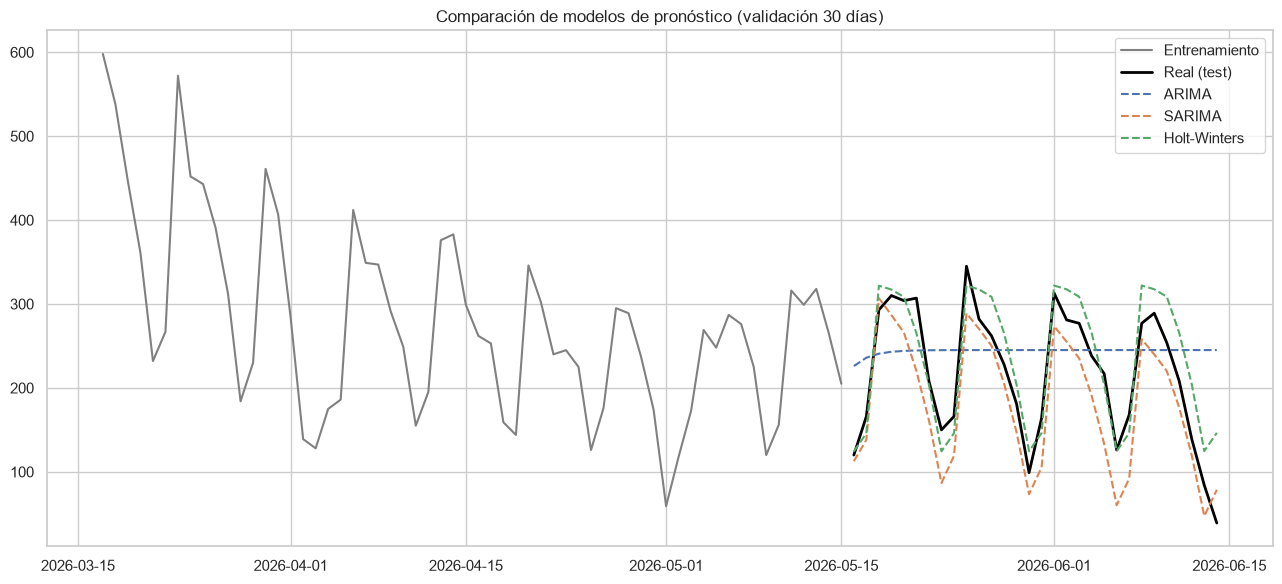

In [31]:
print('='*70); print('PUNTO EXTRA — COMPARACIÓN DE MODELOS DE PRONÓSTICO'); print('='*70)
try:
    serie_c = ts_df['CASOS_DIARIOS']
    h = 30
    train, test = serie_c.iloc[:-h], serie_c.iloc[-h:]

    m_arima  = ARIMA(train, order=(1, 1, 1)).fit();                                   f_arima  = m_arima.forecast(h)
    m_sarima = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)).fit(disp=0); f_sarima = m_sarima.forecast(h)
    m_hw     = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=7).fit(); f_hw = m_hw.forecast(h)

    def metricas(y_true, y_pred):
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        mape = np.mean(np.abs((y_true.values - np.asarray(y_pred)) /
                              y_true.replace(0, np.nan).values)) * 100
        return rmse, mae, mape

    mets = [metricas(test, f) for f in [f_arima, f_sarima, f_hw]]
    tabla = pd.DataFrame({'Modelo': ['ARIMA(1,1,1)', 'SARIMA(1,1,1)(1,0,1,7)', 'Holt-Winters'],
                          'RMSE': [m[0] for m in mets],
                          'MAE':  [m[1] for m in mets],
                          'MAPE(%)': [m[2] for m in mets]})
    print(tabla.round(3).to_string(index=False))
    print(f"\nMejor modelo por RMSE: {tabla.loc[tabla['RMSE'].idxmin(), 'Modelo']}")

    plt.figure(figsize=(13, 6))
    plt.plot(train.index[-60:], train.iloc[-60:], label='Entrenamiento', color='gray')
    plt.plot(test.index, test, label='Real (test)', color='black', lw=2)
    plt.plot(test.index, f_arima,  '--', label='ARIMA')
    plt.plot(test.index, f_sarima, '--', label='SARIMA')
    plt.plot(test.index, f_hw,     '--', label='Holt-Winters')
    plt.title('Comparación de modelos de pronóstico (validación 30 días)')
    plt.legend(); plt.tight_layout(); plt.show()
except Exception as e:
    print('No se pudo ejecutar la comparación de pronósticos:', e)

## 19.4 Pronósticos por entidad federativa

Ajustamos un ARIMA por estado para las 6 entidades con más registros y proyectamos 14 días.

PUNTO EXTRA — PRONÓSTICOS POR ENTIDAD FEDERATIVA


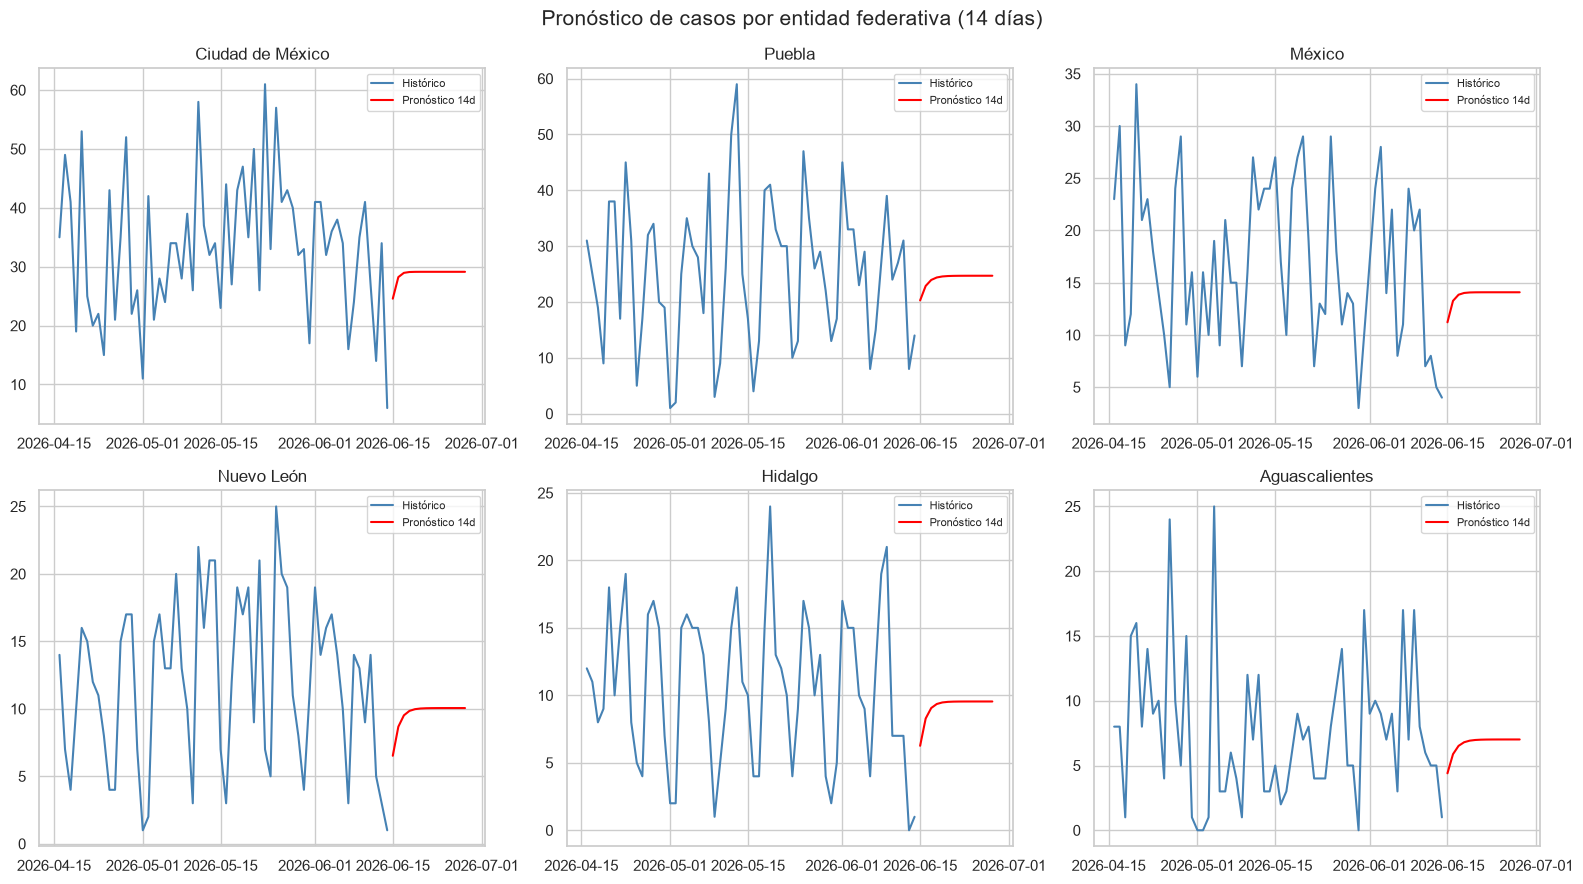

In [32]:
print('='*70); print('PUNTO EXTRA — PRONÓSTICOS POR ENTIDAD FEDERATIVA'); print('='*70)
nombres_estados = {
    1:'Aguascalientes',2:'Baja California',3:'Baja California Sur',4:'Campeche',5:'Coahuila',
    6:'Colima',7:'Chiapas',8:'Chihuahua',9:'Ciudad de México',10:'Durango',11:'Guanajuato',
    12:'Guerrero',13:'Hidalgo',14:'Jalisco',15:'México',16:'Michoacán',17:'Morelos',
    18:'Nayarit',19:'Nuevo León',20:'Oaxaca',21:'Puebla',22:'Querétaro',23:'Quintana Roo',
    24:'San Luis Potosí',25:'Sinaloa',26:'Sonora',27:'Tabasco',28:'Tamaulipas',29:'Tlaxcala',
    30:'Veracruz',31:'Yucatán',32:'Zacatecas'}
try:
    top = (df[df['ENTIDAD_RES'].between(1, 32)]['ENTIDAD_RES']
           .value_counts().head(6).index.tolist())
    fig, axes = plt.subplots(2, 3, figsize=(16, 9)); axes = axes.ravel()
    for i, e in enumerate(top):
        s = (df[df['ENTIDAD_RES'] == e].groupby('FECHA_INGRESO').size()
             .asfreq('D').fillna(0))
        try:
            mod = ARIMA(s, order=(1, 1, 1)).fit()
            fc = mod.get_forecast(14)
            axes[i].plot(s.index[-60:], s.iloc[-60:], color='steelblue', label='Histórico')
            axes[i].plot(fc.predicted_mean.index, fc.predicted_mean, color='red', label='Pronóstico 14d')
            axes[i].legend(fontsize=8)
        except Exception as ex:
            axes[i].text(0.5, 0.5, f'Error: {ex}', ha='center')
        axes[i].set_title(nombres_estados.get(e, str(e)))
    fig.suptitle('Pronóstico de casos por entidad federativa (14 días)', fontsize=15)
    plt.tight_layout(); plt.show()
except Exception as e:
    print('No se pudo ejecutar el pronóstico por entidad:', e)

## 19.5 Dashboard interactivo (Plotly)

Tablero interactivo (zoom, *hover*, selección) con la evolución temporal, el pronóstico, los
casos por entidad y la distribución de edad.

In [33]:
print('='*70); print('PUNTO EXTRA — DASHBOARD INTERACTIVO (PLOTLY)'); print('='*70)
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    fig = make_subplots(rows=2, cols=2,
                        subplot_titles=('Casos diarios', 'Pronóstico de casos (30 días)',
                                        'Casos por entidad (Top 10)', 'Distribución de edad'))

    # 1. Casos diarios
    fig.add_trace(go.Scatter(x=ts_df.index, y=ts_df['CASOS_DIARIOS'],
                             mode='lines', name='Casos', line=dict(color='steelblue')), row=1, col=1)

    # 2. Pronóstico
    fig.add_trace(go.Scatter(x=ts_df.index[-60:], y=ts_df['CASOS_DIARIOS'].iloc[-60:],
                             mode='lines', name='Histórico', line=dict(color='blue')), row=1, col=2)
    fig.add_trace(go.Scatter(x=pred_casos.predicted_mean.index, y=pred_casos.predicted_mean,
                             mode='lines', name='Pronóstico', line=dict(color='red')), row=1, col=2)

    # 3. Casos por entidad
    if 'ENTIDAD_RES' in df.columns:
        ent = (df[df['ENTIDAD_RES'].between(1, 32)]['ENTIDAD_RES']
               .value_counts().head(10).sort_values())
        fig.add_trace(go.Bar(x=ent.values, y=[nombres_estados.get(i, str(i)) for i in ent.index],
                             orientation='h', marker_color='teal', name='Casos'), row=2, col=1)

    # 4. Distribución de edad
    fig.add_trace(go.Histogram(x=df['EDAD'], nbinsx=30, marker_color='salmon', name='Edad'), row=2, col=2)

    fig.update_layout(height=850, width=1100, showlegend=False,
                      title_text='Dashboard interactivo — COVID-19 México')
    fig.show()
except Exception as e:
    print('No se pudo generar el dashboard interactivo:', e)

PUNTO EXTRA — DASHBOARD INTERACTIVO (PLOTLY)
